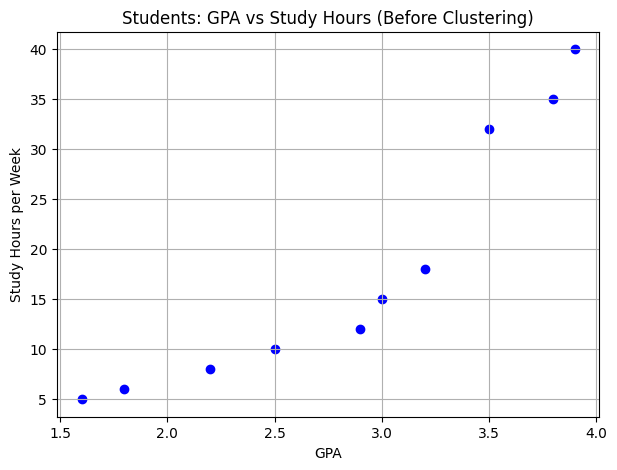

=== Students with Assigned Clusters (K=3) ===
 StudentID  GPA  Study Hours per Week  Cluster
         1  2.5                    10        1
         2  3.0                    15        1
         3  3.2                    18        1
         4  3.8                    35        0
         5  2.9                    12        1
         6  1.8                     6        2
         7  2.2                     8        2
         8  3.9                    40        0
         9  3.5                    32        0
        10  1.6                     5        2

=== Cluster-wise Mean GPA and Study Hours ===
          GPA  Study Hours per Week
Cluster                            
0        3.73                 35.67
1        2.90                 13.75
2        1.87                  6.33

=== Cluster Centroids (Original Scale) ===
          GPA  Study Hours per Week
Cluster                            
0        3.73                 35.67
1        2.90                 13.75
2        1.87         

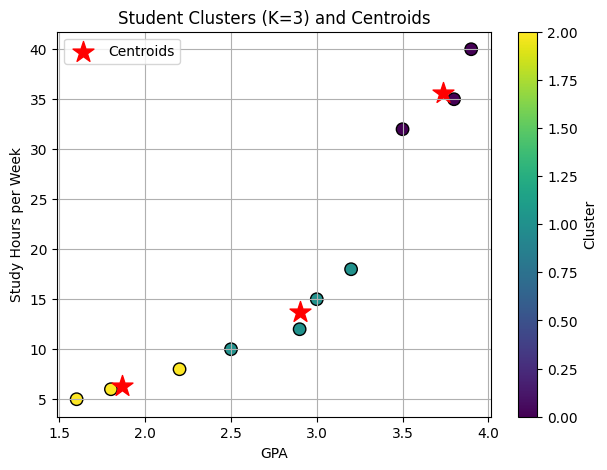


New student (GPA=3.2, Hours=25) belongs to Cluster: 1


c:\Users\KLH\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'StudentID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'GPA': [2.5, 3.0, 3.2, 3.8, 2.9, 1.8, 2.2, 3.9, 3.5, 1.6],
    'Study Hours per Week': [10, 15, 18, 35, 12, 6, 8, 40, 32, 5]
}
df = pd.DataFrame(data)

plt.figure(figsize=(7, 5))
plt.scatter(df['GPA'], df['Study Hours per Week'], color='blue')
plt.xlabel('GPA')
plt.ylabel('Study Hours per Week')
plt.title('Students: GPA vs Study Hours (Before Clustering)')
plt.grid(True)
plt.show()

X = df[['GPA', 'Study Hours per Week']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("=== Students with Assigned Clusters (K=3) ===")
print(df.to_string(index=False))

cluster_means = (
    df.groupby('Cluster')[['GPA', 'Study Hours per Week']]
    .mean()
    .round(2)
)
print("\n=== Cluster-wise Mean GPA and Study Hours ===")
print(cluster_means.to_string())

centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids, columns=['GPA', 'Study Hours per Week'])
centroid_df.index.name = 'Cluster'

print("\n=== Cluster Centroids (Original Scale) ===")
print(centroid_df.round(2).to_string())

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    df['GPA'],
    df['Study Hours per Week'],
    c=df['Cluster'],
    cmap='viridis',
    s=80,
    edgecolor='k'
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='*',
    s=250,
    label='Centroids'
)

plt.xlabel('GPA')
plt.ylabel('Study Hours per Week')
plt.title('Student Clusters (K=3) and Centroids')
plt.grid(True)
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

new_student = np.array([[3.2, 25]])   
new_scaled = scaler.transform(new_student)
predicted_cluster = kmeans.predict(new_scaled)[0]
print(f"\nNew student (GPA=3.2, Hours=25) belongs to Cluster: {predicted_cluster}")
